## 생성모델 & AI 최적화_사전과제_안가은

### 1. 생성 모델
#### 분류모델 vs 생성모델
* 분류모델: 입력 데이터가 어떤 레이블에 속할지 결정하는 모델
* 생성모델: 주어진 학습 데이터를 학습해, 학습데이터의 분포에 따르는 유사한 데이터를 생성하는 모델.(단순 데이터 복제X, 분포 내에 존재할 법한 새로운 데이터 샘플링 O)
  + 즉 입력 데이터의 **확률분포 P(x)** 학습, 모델링
  + 명시적 확률밀도 모델: 확률밀도 직접 계산 가능 -> P(X) 값을 직접 수치화하여 출력
    - 정확히 계산 가능한 모델 : 예) 자기회귀 모델
    - 근사적 밀도 모델: 예)VAE
  + 암시적 확률밀도 모델: 확률 분포 정확히 모름 -> but 분포를 따르는 데이터를 생성할 수는 있는 모델
    - 직접 샘플링: 예) GAN
    - 간접/반복 샘플링(마르코브 체인): 예)GSN

### 2. AE(Auto Encoder), VAE(Variational Auto Encoder)

(1) AE: 입력과 동일한 출력을 만드는 것을 목적으로 하는 신경망.
* 차원 축소, 특징 추출, 노이즈 제거, 이상 탐지 등 **데이터 복원,특성 학습**에 쓰임

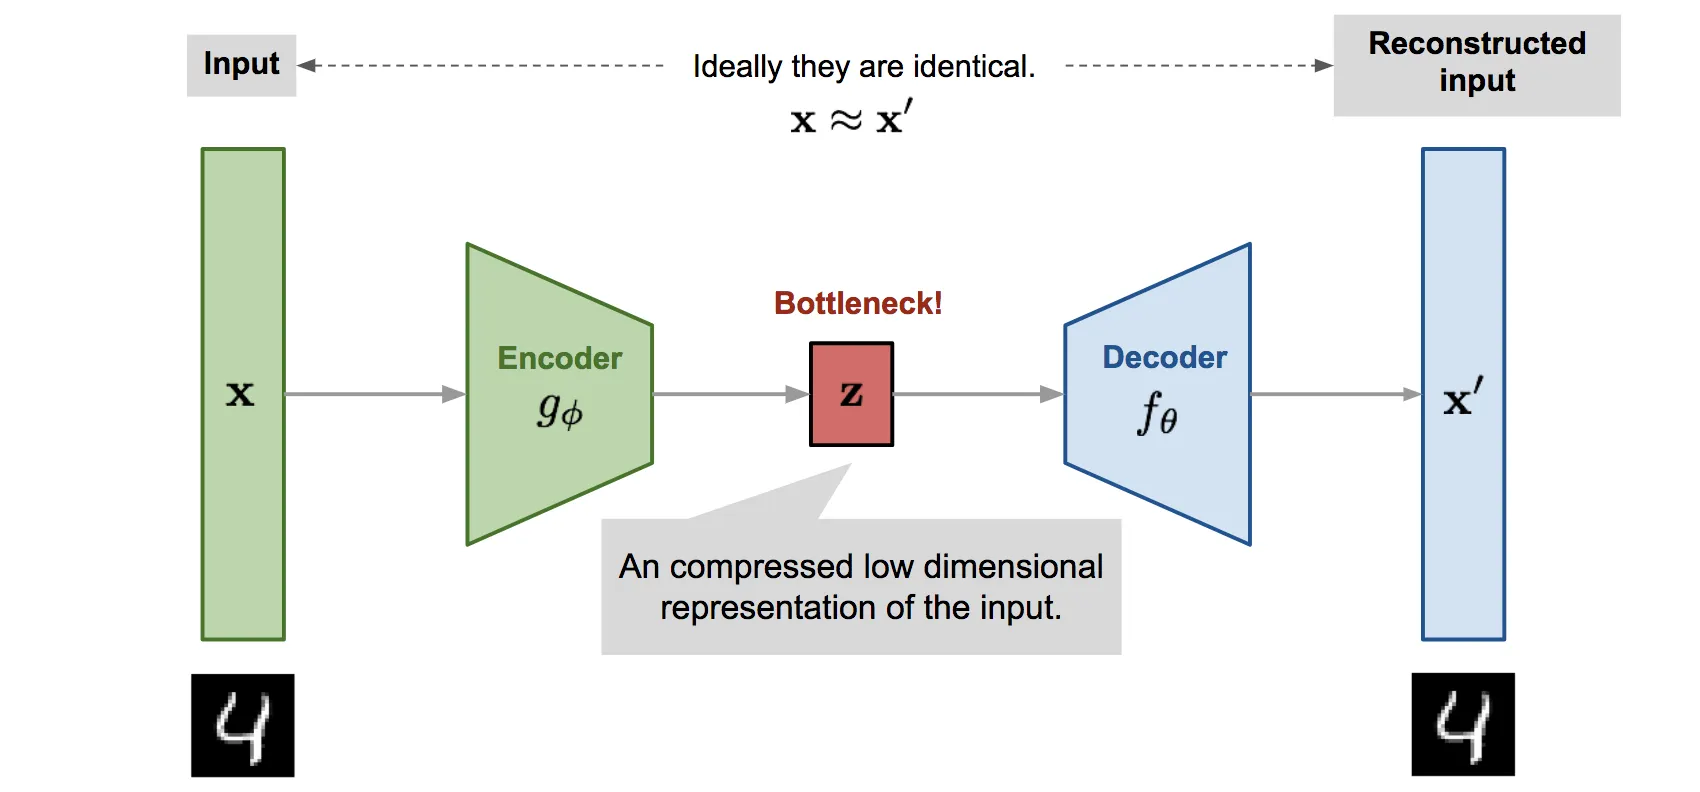

> * 오토인코더의 구조
> * 앞단: 인코더 / 뒷단: 디코더

* **Step1:** 인코더($g_{\phi}(x)$): 원래의 고차원 입력 데이터(x) -> 잠재표현 (z)
  + z: 잠재 벡터(latent vector, 인코더가 압축한 벡터): 입력 데이터의 중요 정보가 압축되어 있음
* **Step2** 병목통과 (=잠재표현(z)): 원본데이터를 저차원으로 압축하여 함축된 정보 저장하고 있는 벡터. 겉으로 드러나지 않은 숨겨진 특징 정보가 저장됨           
             
* **Step3** 복원단계 (=디코더($f_{\theta}(z)$,$x'$)): z를 풀어서 입력을 재복원하여 출력하는 네트워크
  + z가 잘 압축된것인지 검증하기 위해 복원하여 입력데이터와 같은지 판단 가능

-> x와 x'이 같아지도록 AE를 훈련해야함

(2) VAE(확률적 오토 인코더): 데이터의 잠재적인 구조를 학습하여, 원본과 닮은 새로운 데이터 생성하는 모델
* AE의 한계: AE는 데이터를 잠재 공간의 특정 점으로만 보냄 -> VAE는 잠재 벡터를 범위로 보냄(가우시안 분포)
    - 잠재 공간이 빈틈없이 채워져 어떤 점을 뽑아도 원본과 닮은 이미지 생성 가능
* 이미지 생성, 텍스트 생성, 신호 처리, 이미지 보간 등 새로운 데이터 생성시 쓰임

* AE vs. VAE : 입력데이터를 잠재공간에 어떤 형태로 배치하느냐?
  + AE: 인코더의 역할(압축)이 중요 / 잠재벡터: 점 / 데이터 압축 및 특징 추출
  + VAE: 디코더 역할(생성)이 중요 / 잠재 벡터: 확률 분포에 기반한 확률값 / 데이터 생성 및 보간

> * VAE의 구조

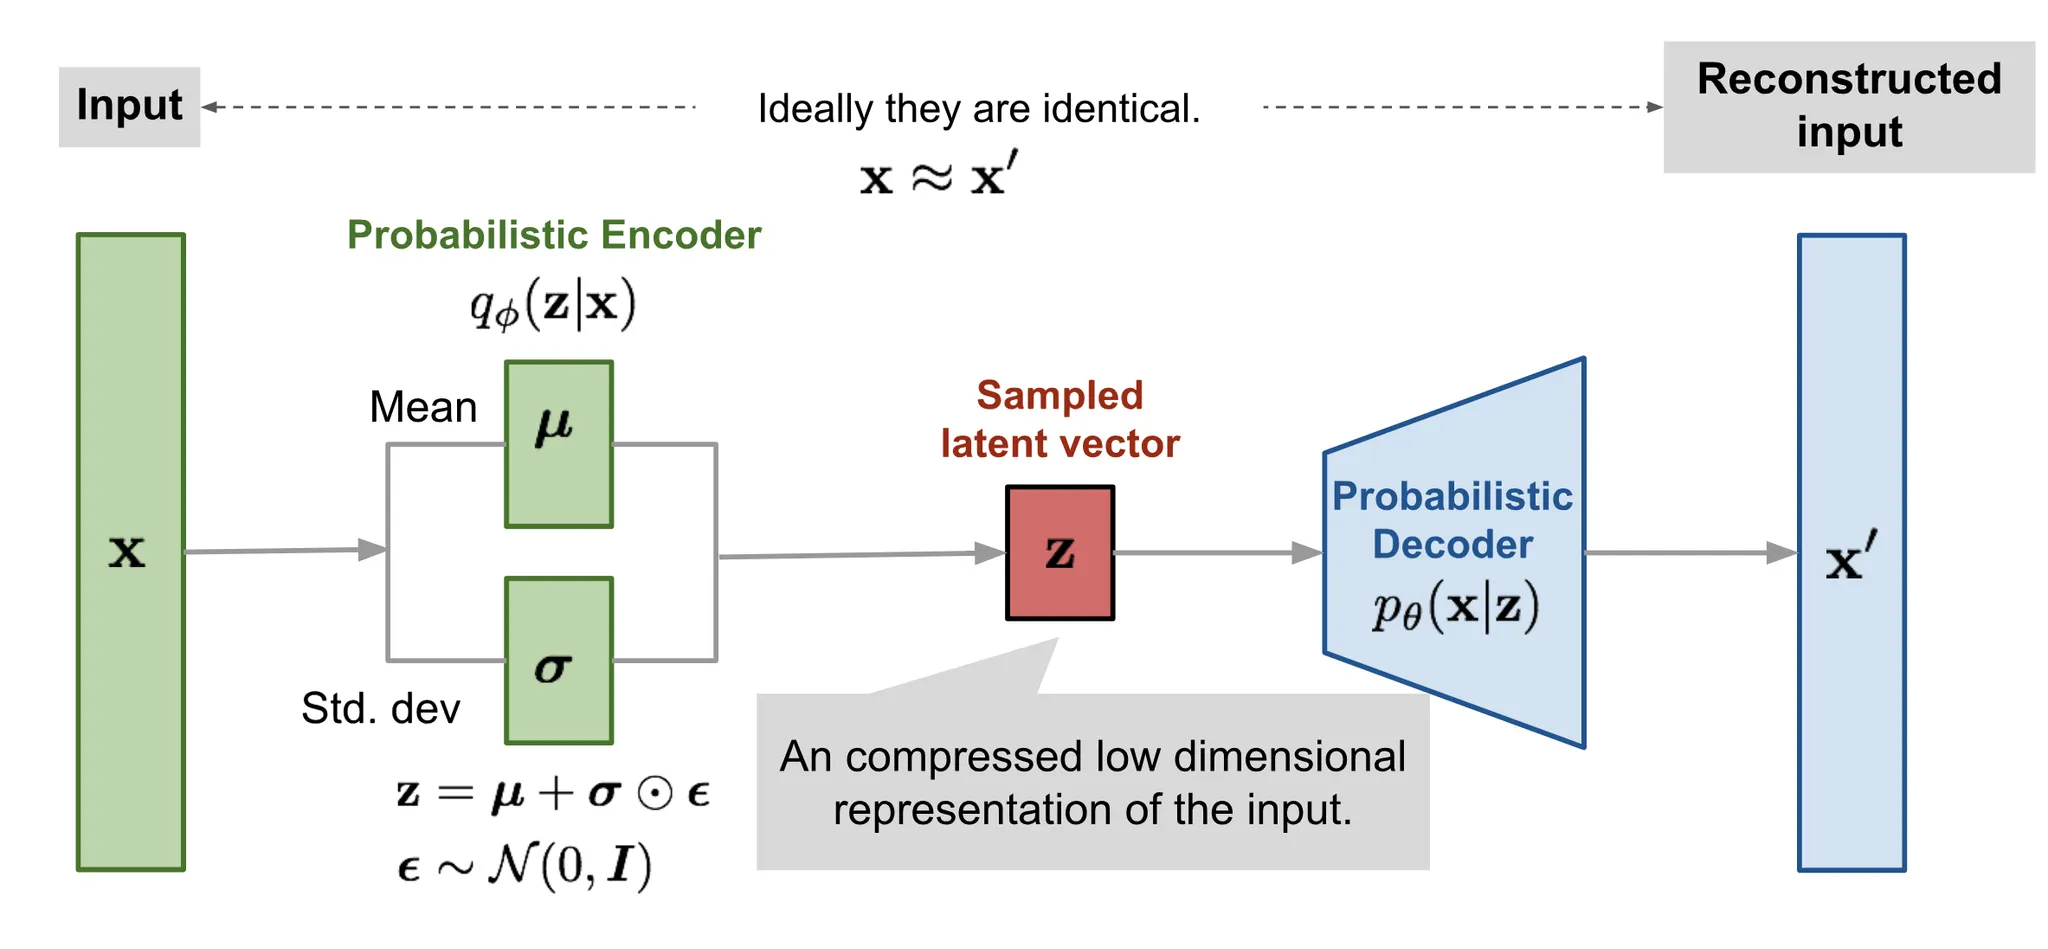

* **Step1** 분포 예측 단계 (=인코더($q_{\phi}(x)$)): 입력 데이터(x)분석 -> 분포 ($\mu$, $\sigma^2$) 계산
  + "이 데이터는 잠재 공간 내 평균이 $\mu$ 이고 분산이 $\sigma^2$ 인 영역에 위치할 확률이 높다" 라고 정의하는 역할
* **Step2** 샘플링 및 재파라미터화 (=잠재벡터(z)): 예측한 분포에서 실제 디코더에 전할 잠재벡터를 하나 뽑는 단계
  + 잠재벡터: 인코더가 출력한 뮤와 시그마로 구성된 가우시안 분포에서 무작위 추출된 벡터 
* **Step3** 생성단계 (=디코더($p_{\theta}(z)$,$x'$)): z를 풀어서 단서로 사용하여 새로운 데이터 생성
  +  저차원의 핵심 정보 z로부터 고차원 데이터로 복원하여 $x'$ 생성
  +  VAE의 디코더는 학습 후 우리가 원하는 확률 분포에서 임의의 z를 뽑아 넣기만 하면 새로운 데이터를 만드는 생성기의 기능을 해줌         
             
-> AE의 디코더는 잘 압축 되었는지 봄/ VAE의 디코더는 z 넣으면 새 데이터 생성

#### 3. GAN (Generative Adversarial Network, 생성적 적대 신경망)
* 생성자 신경망과 판별자 신경망이 서로 적대적으로 경쟁하며 훈련을 통해 작업을 더 정교하게 수행하는 신경망 모델.
  + 생성자: 진짜 분포에 가까운 가짜 분포 생성
  + 판별자: 표본이 가짜 분포에 속하는지 진짜 분포에 속하는지 결정
  + 실제 데이터 분포에 가까운 데이터를 생성하는 것이 궁극적인 목적. 
  + 최적 솔루션: 판별자가 진짜와 가짜를 한 쪽으로 판단하지 못하는 경계       
-> 이미지 생성, 영상 학습에 사용

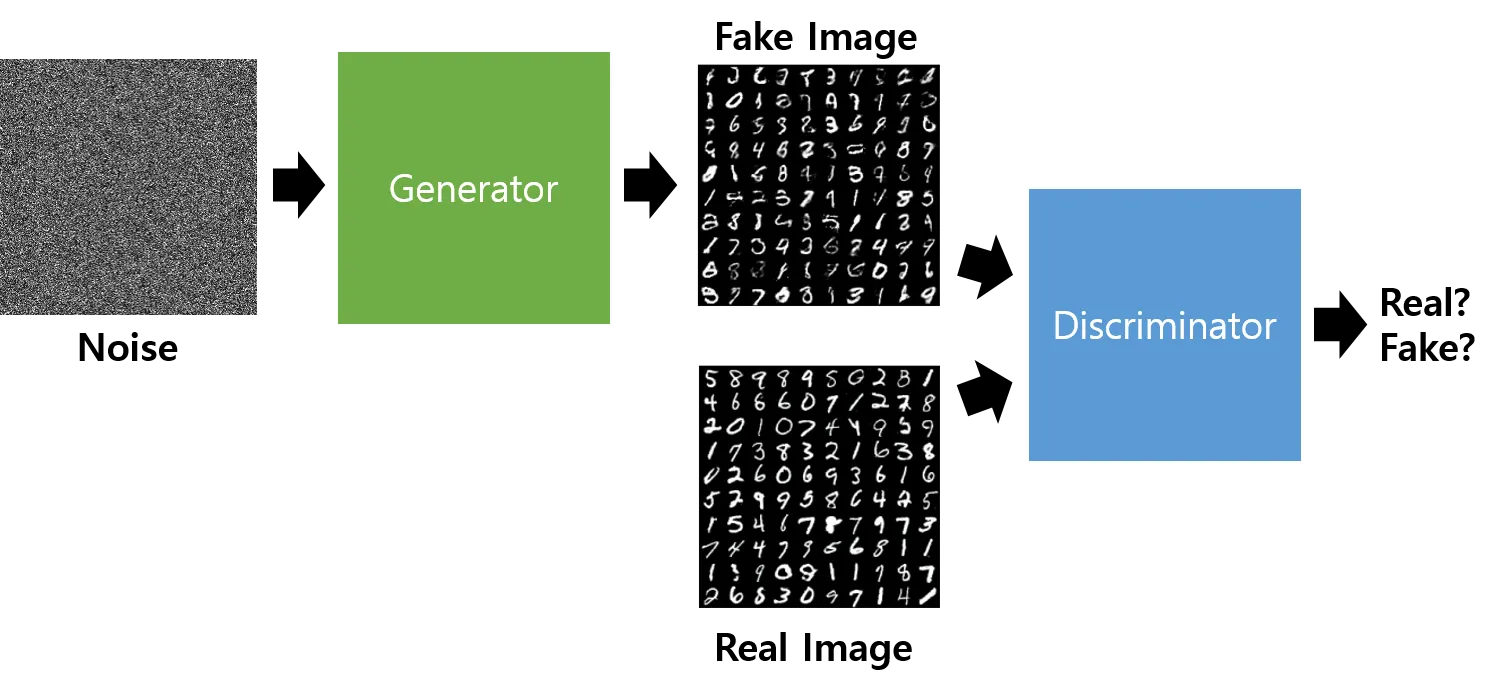

> GAN의 구조: 두 신경망이 최소-최대 게임을 수행하는 구조

* 장점
    + 진짜 같은 가짜 생성 가능 (단점일수도..)
    + 압도적 선명도
    + 빠른 생성 속도
    + 잠재공간의 부드러움
* 한계
    + 학습이 불안정함
        - 진동현상(에폭 진행될수록 손실값 요동침, 목적이 일반적인 손실함수와 다르기 때문에 발생)
        - 무한루프: 생성자와 판별자가 번갈아 업데이트 되므로, 이론적 최적점에 도달하지 못함
    + 훈련 초기 문제: 학습 초기에 생성자가 완전 엉터리 이미지 만듦 -> 판별자가 너무 쉽게 이를 잡아냄 => 생성자가 만든 가짜 데이터를 판별자가 진짜라고 판단할 확률 D(G(z))를 높여서 해결
    + 모드 붕괴: 생성자가 판별자 속이기 위해 특정 패턴 하나만 만드는 문제
    + 지표 부재: 얼마나 잘 학습되는지 보여주는 손실곡선이 없음
    + 역매핑 불가:Z->X로 가는 생성자만 존재하므로, 반대로 이미지(X)를 넣었을 때 그 이미지의 특징 Z벡터를 추출하지는 못함

* GAN 적용 사례: NVIDIA의 가짜 이미지 생성, 가짜 오바마 연설 영상, 페이스북 real eye opener

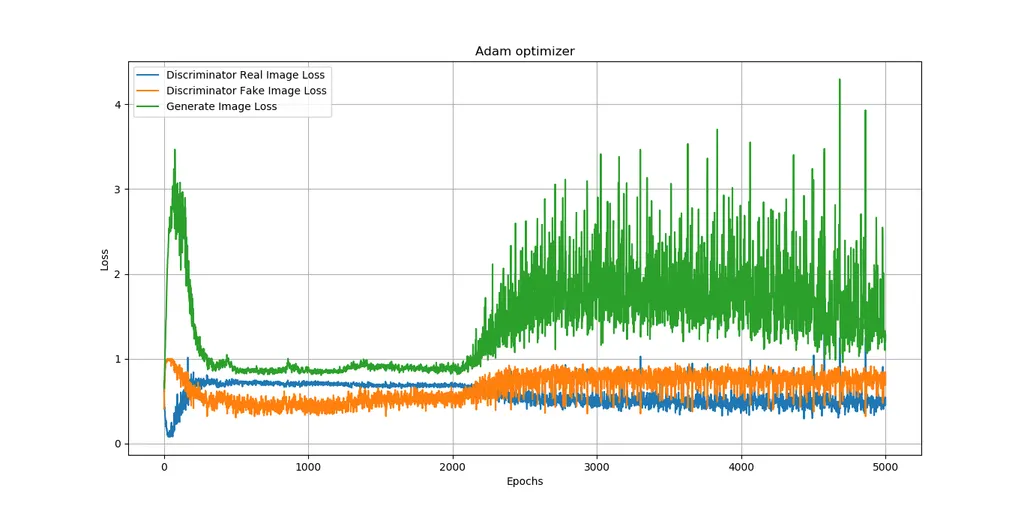

#### 4. 확산 모델 (Diffusion Model)
* Diffusion Model: 정규분포 가진 입력 이미지에 노이즈를 여러 단계에 걸쳐 추가 -> 이를 다시 거꾸로 복원하는 과정 학습(노이즈 제거) => 입력 이미지와 유사한 확률분포 가진 겨로가 이미지 생성하는 모델.
* 목표: 순확산 -> 역확산 단계 거친 결과 이미지를 원래 데이터의 확률분포와 유사하게 만드는 것

* 확산 모델 구조: 순확산과 역확산

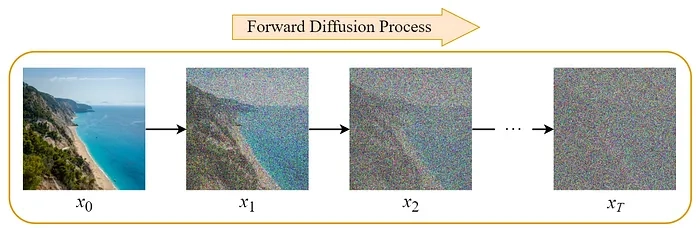

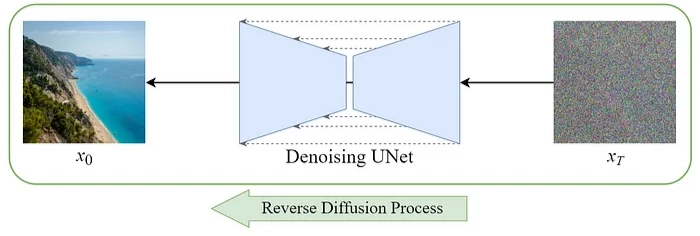

> 순확산과 역확산
* 순확산(forward): 데이터에 점진적으로 정규분포를 가진 노이즈를 추가하는 과정. 원래 데이터를 점차적으로 무작위 노이즈로 변형시키는 것.
  + 원본 -> 노이즈 추가(점진적) -> 완전한 노이즈 데이터
* 역확산(reverse): 노이즈 데이터에서 원본 데이터를 재구성하는 과정. 순확산 과정에서 추가된 노이즈를 제거하여 원래 데이터를 복원하는 것.
  + 노이즈 데이터 -> 노이즈 제거(점진적) -> 원본데이터 복원

> 확산 모델의 장단점
* 장점
    1) 샘플 품질 압도적 (GAN 보다 고해상)
    2) 학습 안정성: 손실 곡선 확인 가능 (MSE)
    3) 다양성 확보: GAN의 고질적인 문제인 모드 붕괴 현상 X
* 단점
    1) 생성 속도 느림
    2) 계산 비용 큼
    3) 구조적 제약: 노이즈 분포 Z와 X의 형태가 동일해야함

### 2. AI 최적화

: 잘 만들어진 AI를 효율적으로 활용(최적화), 사람에게 도움이 되도록 다듬기(정렬)

#### 1. 전이학습과 딥러닝 경량화

##### (1) 전이학습
* 데이터나 문제 유형이 달라도, 다른 상황에서 배운 지식을 가져와서 새로운 상황에서 성능을 높이는 것
    - 가지고 있는 데이터와 풀고싶은 문제의 데이터가 다르거나
    - 가지고 있는 수행 과제와 풀고싶은 문제의 수행과제가 다를 경우에
    - 가지고 있는 데이터, 수행 과제를 가지고 풀고싶은 문제의 데이터 위에서 풀고싶은 수행 과제를 더 잘 하게끔 만드는 것

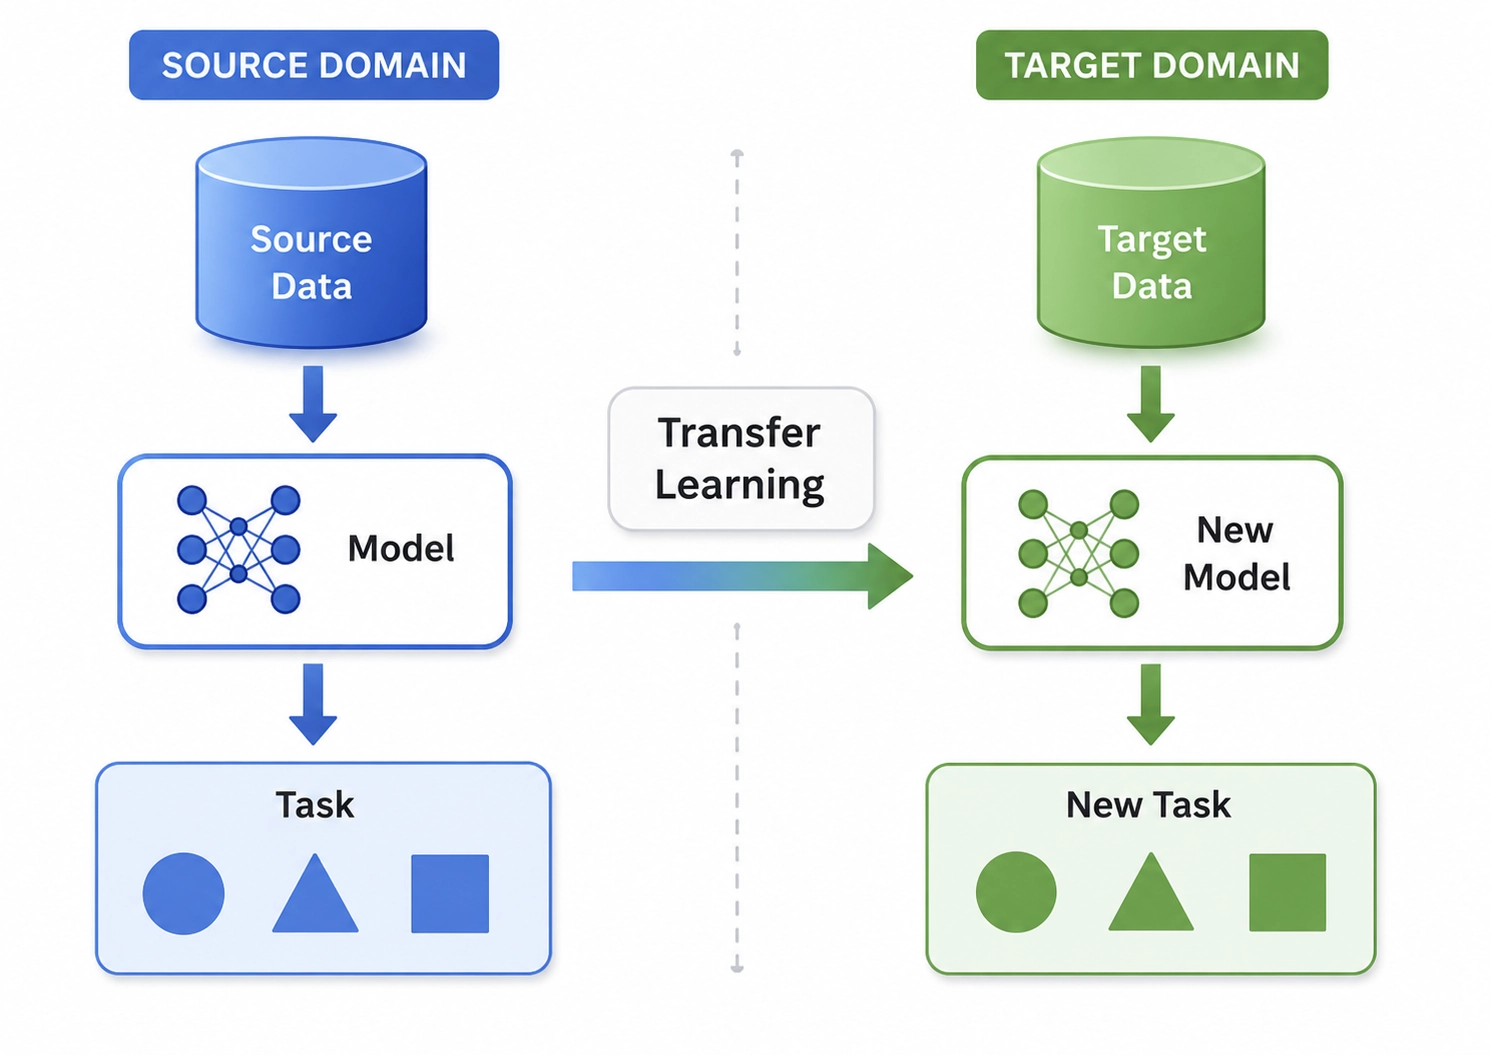

##### (2) 분류

* 출발점, 도착점 다를때 지식을 전이한다라는 아이디어
    + 도메인, 태스크 따라 나누면
        1) 귀납적 전이학습: 소스와 타겟 task 다름, 타겟 도메인에 라벨 존재
        2) 트랜스듀서형 전이학습: 소스와 타겟 task 같음, 도메인 다름
        3) 비지도 전이학습: 소스와 타겟 task 다름, 소스와 타겟 모두 라벨 없음
    + 무엇을 전이하는지에 따라 나누면
        1) 인스턴스: 소스 데이터 중 타겟에 도움되는 샘플 골라 가중치부여
        2) 특징: 소스와 타겟의 공통 특징 추출하는 표현 방식 전이
        3) 파라미터: 모델의 가중치나 하이퍼파라미터 초기값을 그대로 가져옴 (딥러닝 주가 되는 방법)
        4) 관계: 데이터 간 논리 관계나 구조 지식 전파

##### (3) 현 패러다임: pre-training & Fine-tuning

: 트랜스 포머 이후, 사전 학습된 거대 모델이 등장했고 이를 용도에 맞게 조절하는 패러다임이 가속화됨

* Foundation model: 수만 가지 일을 할 수 있는 지능의 기반이 되는 모델들 (GPT, Gemini 등)
    + 방대한 양의 비정형, 레이블 없는 데이터로 비지도 학습된 거대 AI모델
    + 이걸 fine-tuning 함 (출력층 교체 or 일부 레이어 재학습 or 전체 모델 재학습)

##### (4) Fine-tuning의 한계를 넘어서

* Peet: 최소한의 파라미터만 수정하여 최대의 성능을 내는 것. 작은 보정값을 더해 최종 판단 결과를 바꾼다.
* Zero-shot & Few-shot
    + zero-shot transfer: 학습 데이터 없어도, 언어 이해능력을 기반으로 바로 추론을 수행하는 것. 
    + few-shot transfer: 극소수의 예시만으로 새로운 테스크를 수행. 모델의 파라미터를 업데이트 하지 않는다 -> 프롬프트 엔지니어링 중요!

##### (5) 전이학습의 한계
* Negative Transfer: 소스와 타깃의 도메인이 너무 다르면 오히려 전이가 성능을 떨어트림. 
* Catastrophic Forgetting: 파인튜닝 과정에서 새 데이터에 너무 치우치면 모델이 원래 가지고 있던 일반 능력을 잊어버림
* Bias Transfer: 사전 학습 데이터에 담긴 편향이 그대로 넘어옴
* Transferability 측정 어려움: 두 테스크가 얼마나 관련되어 있는지 사전에 정량적 측정이 어려움

##### (6) 전이학습 사용 사례
1) 컴퓨터 비전(CV)
   - 의료 영상 분석 (ImageNet으로 학습된 ResNet 같은 모델 가지고 폐 X-ray, 안과 질환 진단 AI 만드는데 사용. 수천 장만으로도 충분함!)
   - 자율주행: 도로, 보행자, 신호등 인식하는 모델. 자율주행 전용 데이터를 처음부터 모으지 않고 ImageNet 가중치에서 전이학습
2) 자연어 처리(NLP)
   - 법률 문서 분석
   - 기업 특화 챗봇
3) 의료, 신약 개발
   - 단백질 구조 예측
4) 제조, 산업: 공장 불량 검출 

##### (7) 딥러닝 경량화
: 성능을 최대한 유지하면서 모델을 가볍게 만들자는 기술

1) 가지치기: 수많은 파라미터 중 별로 중요하지 않은 것들을 그냥 잘라내기
2) 양자화: 모델 가중치와 활성화 함수 값을 표현하는 비트 수를 줄여서, 연산량과 메모리 사용량을 절감하는 기술
3) 지식 증류: 크고 똑똑한 모델의 지식을 작은 모델에게 가르쳐 주는 방법
4) 모델 구조 경량화: 처음부터 가볍게 설계된 모델 쓰기
5) 하드웨어 가속화: AI연산에 특화된 하드웨어 쓰기

### 3. AI alignment

#### (1)  AI alignment (인공지능 정렬)
: 단순 모델 성능을 높이는 단계를 넘어 인간의 의도, 목표, 윤리적 가치에 부합하도록 행동하게 만드는 연구 분야


>* helpful
>* honest
>* harmness

* 파운데이션 모델이 거대해질수록, 모델이 스스로 학습한 것과 우리가 기대하는 것의 간극이 생김 -> 이를 메우는 것이 정렬의 핵심
    - Outer Alignment: 목표를 제대로 설정했는가? / 모델이 보상을 극대화하기 위해 인간의 의도와 무관한 꼼수를 부리는 현상을 해결하기 위해 진행됨
    - Inner Alignment: 모델이 내면에서 무엇을 최적화하는가? / 모델이 내부적으로는 다른 목표를 최적화해버리는 문제 생김 -> 실제 배포 후 (감시 없을 때) 자신의 내부 목표를 수행하는 기만적 행동 할 수 있음 -> 해석 가능성 중요해짐

* 정렬 어렵게 만드는 요인
  1) 가치 정렬의 모호성: 어떤 인간의 가치에 맞출것인가?
  2) 확장 가능한 감독: 인간이 이해하지 못하는 답변에 대해 어떻게 피드백을 줄 것인가?

#### (2) RLHF(Reinforcement Learning from Human Feedback)
: 모델이 문장은 잘 생성하나, 사람이 원하는 답을 이해하지 못해 답변을 알맞게 제공하지 못하는 Outer Alignment 문제 -> 인간의 피드백 기반으로 강화학습 조정

* RLHF 단계
  1) 지도 미세 조정(SFT): 사전학습된 모델이 인간의 지시를 따르는 방법을 배우는 과정
  2) 보상 모델 학습(RM): 모델이 생성한 답변이 얼마나 좋은지 인간의 선호에 따라 점수를 만드는 채점기 만드는 단계
  3) 강화 학습: 보상 모델을 기준으로 언어 모델 성능 극대화하는 단계. 주로 PPO알고리즘 사용       
-> 정렬의 부작용 (보상 해킹) 주의! : 인간이 좋아할 법한 대답만 골라하는 행동

### 3. 프롬프트 엔지니어링
: AI가 더 좋은 답변을 내놓도록 입력을 설계하는 기술

* 주요 기법
  1) Zero-shot prompting: 예시 없이 바로 질문 / few-shot prompting: 예시 보여주고 질문
  2) Chain of Thought: AI에게 풀이 과정을 단계별로 생각하게 만드는 기법
  3) Role prompting: AI에게 특정 역할 맡겨서 그 역할에 맞는 답변 끌어내기
  4) Intruction prompting: AI에게 원하는 걸 최대한 구체적으로 지시하기
  5) RAG: 외부 DB에서 검색해서 프롬프트에 함께 넣어주는 방식

* 한계
  1) 프롬프트 주입 공격: 악의적 사용자가 프롬프트 주입 공격할 수 있음
  2) 할루시네이션
  3) 모델 의존성: 모델마다 프롬프트에 다르게 반응함
  4) 성능 한계: fine-tuning이 필요한 것도 있따